## Data Cleaning

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests

url_data = "https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data"
url_names = "https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.names"

names = []

response = requests.get(url_names)
for line in response.text.split("\n"):
    if line.startswith("@attribute"):
        names.append(line.split()[1])

df = pd.read_csv(url_data, names=names, na_values='?')

df = df.dropna(thresh=len(df) * 0.5, axis=1)
df = df.fillna(df.median(numeric_only=True))

print("Датасет готовий!")
print(f"Кількість стовпців: {df.shape[1]}")

Датасет готовий!
Кількість стовпців: 104


## Залежність рівня злочинності від рівня бідності

Важливо:
у датасеті всі числові значення вже нормовані в діапазоні 0–1.
Тому точки на краях графіка є нормальним явищем.

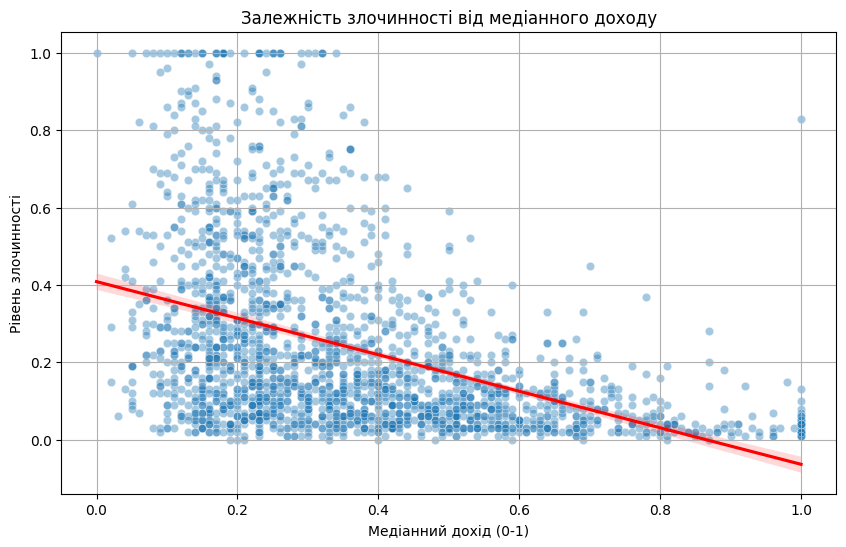

In [62]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["medIncome"],
    y=df["ViolentCrimesPerPop"],
    alpha=0.4
)

sns.regplot(
    x=df["medIncome"],
    y=df["ViolentCrimesPerPop"],
    scatter=False,
    color="red"
)

plt.title("Залежність злочинності від медіанного доходу")
plt.xlabel("Медіанний дохід (0-1)")
plt.ylabel("Рівень злочинності")
plt.grid(True)
plt.show()


## Розподіл рівня бідності за 5 діапазонами

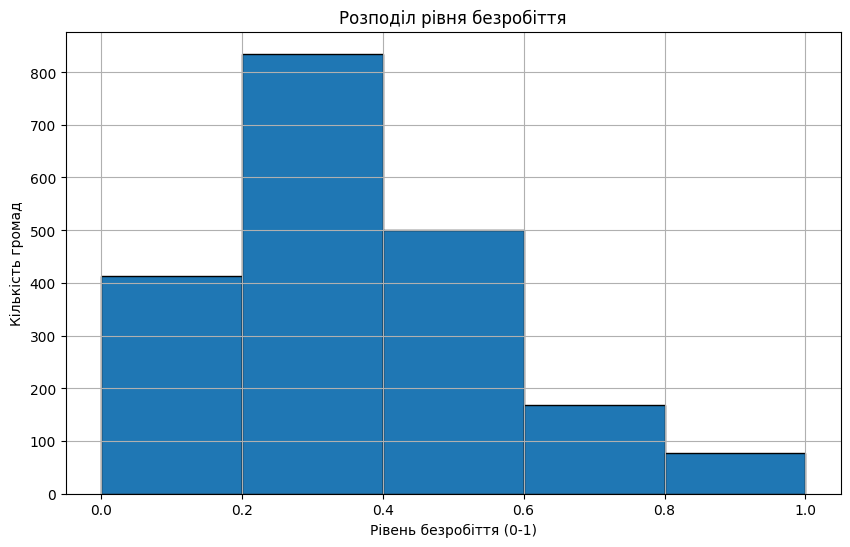

In [71]:
plt.figure(figsize=(10,6))

plt.hist(
    df["PctUnemployed"],
    bins=5,
    edgecolor="black"
)

plt.title("Розподіл рівня безробіття")
plt.xlabel("Рівень безробіття (0-1)")
plt.ylabel("Кількість громад")

plt.grid(True)

plt.show()

## Порівняння розподілу злочинності за рівнями доходу (Box Plot)

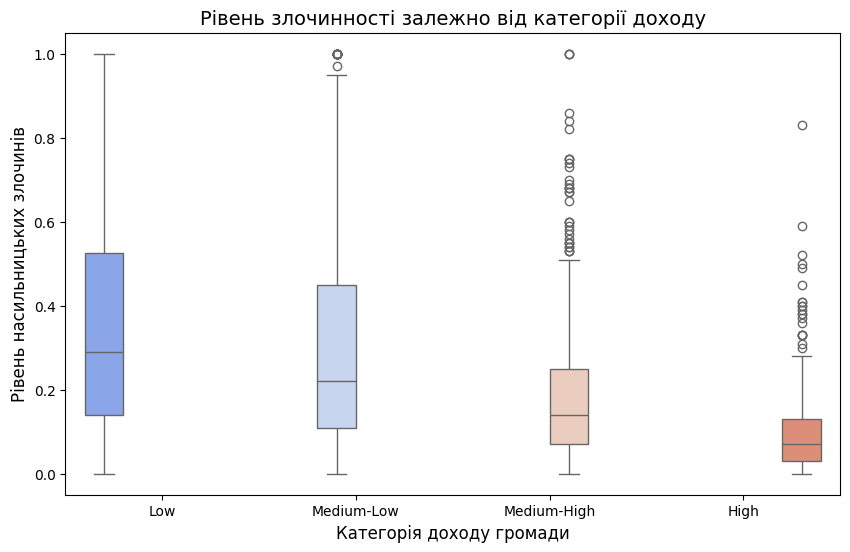

In [75]:
df = df.copy()

df['income_level'] = pd.qcut(
    df['medIncome'].rank(method='first'),
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='income_level',
    y='ViolentCrimesPerPop',
    hue='income_level',
    palette='coolwarm',
    legend=False
)

plt.title('Рівень злочинності залежно від категорії доходу', fontsize=14)
plt.xlabel('Категорія доходу громади', fontsize=12)
plt.ylabel('Рівень насильницьких злочинів', fontsize=12)

plt.show()

## Багатовимірна візуалізація: Вплив бідності та безробіття (Bubble Chart)

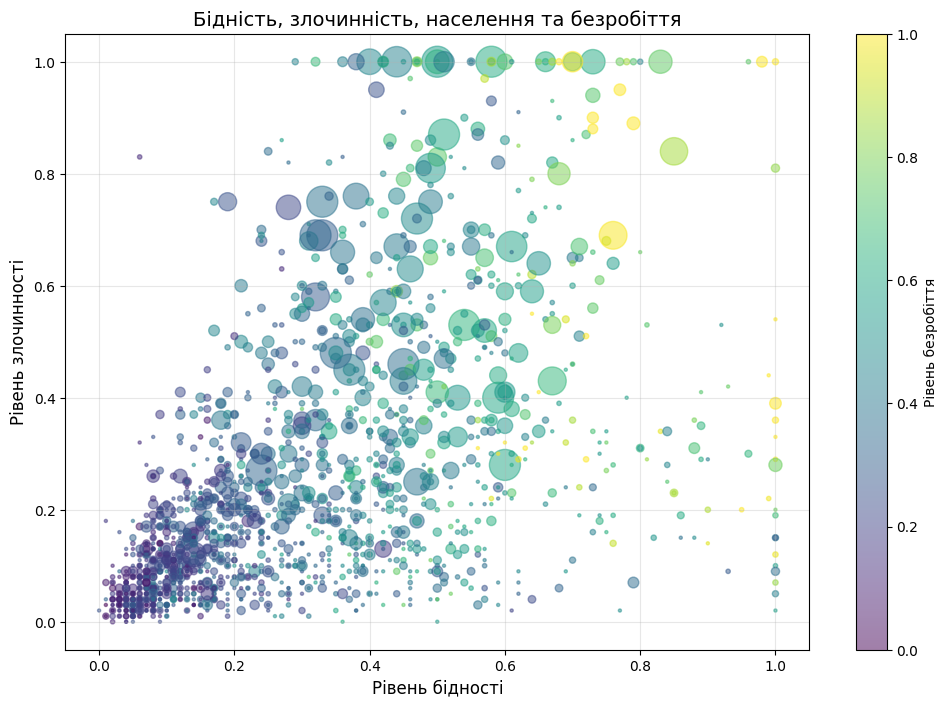

In [76]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df['PctPopUnderPov'],          # бідність
    df['ViolentCrimesPerPop'],     # злочинність
    s=df['population'] * 500,      # населення
    c=df['PctUnemployed'],         # безробіття
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(scatter, label='Рівень безробіття')

plt.title('Бідність, злочинність, населення та безробіття', fontsize=14)
plt.xlabel('Рівень бідності', fontsize=12)
plt.ylabel('Рівень злочинності', fontsize=12)

plt.grid(True, alpha=0.3)
plt.show()

## Матриця кореляції топ-показників (Heatmap)

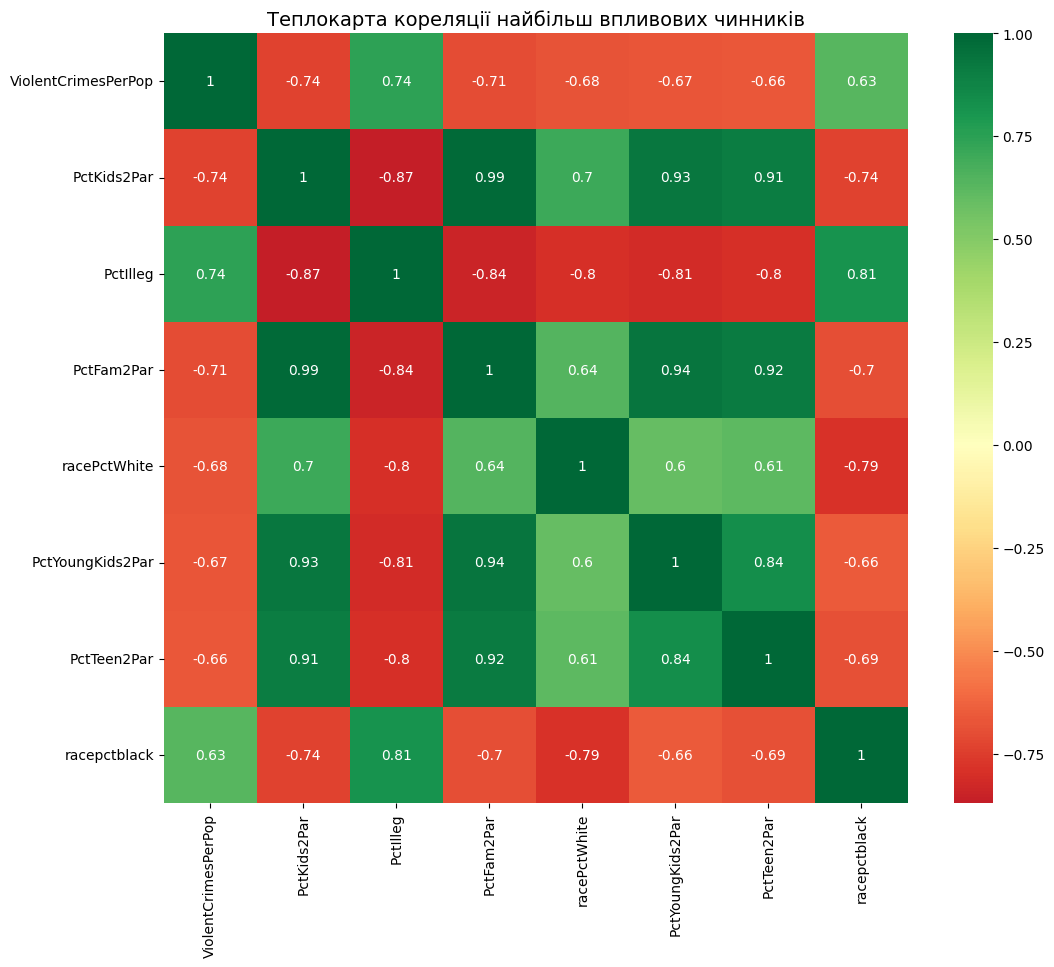

In [77]:
target_corr = df.corr(numeric_only=True)['ViolentCrimesPerPop'].abs().sort_values(ascending=False)

top_features = target_corr.head(8).index

corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdYlGn',
    center=0
)

plt.title('Теплокарта кореляції найбільш впливових чинників', fontsize=14)

plt.show()

## Розподіл безробіття за категоріями доходу (Violin Plot)

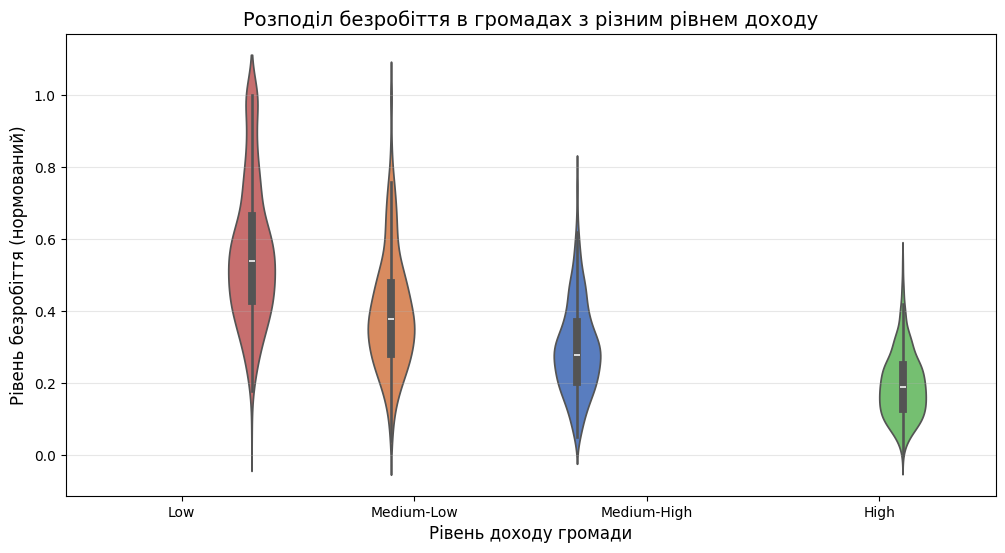

In [78]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='income_level',
    y='PctUnemployed',
    hue='income_level',
    palette='muted',
    legend=False
)

plt.title('Розподіл безробіття в громадах з різним рівнем доходу', fontsize=14)
plt.xlabel('Рівень доходу громади', fontsize=12)
plt.ylabel('Рівень безробіття (нормований)', fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.show()

## Висновки

Дані нормовані в діапазоні 0–1.
Медіанний дохід має слабку кореляцію зі злочинністю.
Бідність та безробіття мають сильніший вплив.
Громади з низьким доходом мають вищий рівень злочинності.